REGRESION SIMPLE
TOMANDO EN CUENTA EL DATASET DESCARGADO, SE UTILIZO TRES COLUMNAS (PRECIO DEL TERRENO, NIVEL DEL TERRENO Y LA "Y" QUE SERIA LOS PISOS QUE PUEDE LLEGAR A TENER CONSIDERANDO LA CARACTERISTICAS ANTERIORES)

In [88]:
# Importar bibliotecas necesarias para manejo de directorios, computación numérica y graficación.
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [89]:
# Montar Google Drive para acceder a los archivos.
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [90]:
# Cargar datos desde un archivo de texto en Google Drive.
# Dividir los datos en características (X) y variable objetivo (y).
# Imprimir el número de ejemplos de entrenamiento y los primeros 10 ejemplos.
# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'ex1data2.txt'), delimiter=',')
data = np.loadtxt('/content/gdrive/MyDrive/Colab Notebooks/DATASETS/DATASET-REAL-ESTATE2.txt', delimiter=',')

# X contains the features (X0 and X1)
X = data[:, :2]
# y contains the target variable
y = data[:, 2]

m = y.size
print(m)

# imprimir algunos puntos de datos
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

10000
  X[:,0] X[:, 1]         y
--------------------------
      25      15        31
      14       5         5
     107       4        13
      31       3         5
      25       2         3
      14       5         5
      90       2         4
      30       1         2
      23      16        18
      23       2         2


In [91]:
# Definir una función para normalizar las características.
# Calcula la media y la desviación estándar de cada característica y luego normaliza los datos.
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [92]:
# Normalizar las características utilizando la función featureNormalize.
# Imprimir los datos originales, la media, la desviación estándar y los datos normalizados.
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[ 24.513   15.    ]
 [ 14.5      5.    ]
 [107.       4.    ]
 ...
 [145.48    22.    ]
 [ 29.5      9.    ]
 [ 25.2247   6.    ]]
Media calculada: [64.35855035  6.7663    ]
Desviación estandar calculada: [447.49085643   5.84707485]
[[-0.08904216  1.40817421]
 [-0.11141803 -0.30208267]
 [ 0.0952901  -0.47310836]
 ...
 [ 0.18128069  2.60535403]
 [-0.07789779  0.38202008]
 [-0.08745173 -0.13105698]]


In [93]:
# Añadir una columna de unos a la matriz de características normalizadas para el término de intercepción.
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [94]:
# Imprimir la matriz de características con la columna de intercepción añadida.
print(X)

[[ 1.         -0.08904216  1.40817421]
 [ 1.         -0.11141803 -0.30208267]
 [ 1.          0.0952901  -0.47310836]
 ...
 [ 1.          0.18128069  2.60535403]
 [ 1.         -0.07789779  0.38202008]
 [ 1.         -0.08745173 -0.13105698]]


In [95]:
# Definir la función para calcular la función de costo (Mean Squared Error).
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [96]:
# Definir la función para realizar el descenso por gradiente.
# Actualiza los parámetros theta iterativamente para minimizar la función de costo.
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [11.99495812  0.1037972   5.47970829]
Los niveles de una casa tomando en cuenta su costo 


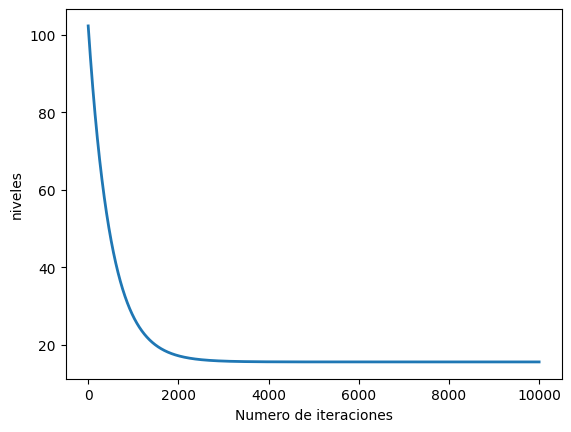

In [97]:
# Configurar los parámetros para el descenso por gradiente (tasa de aprendizaje alfa y número de iteraciones).
# Inicializar theta y ejecutar el descenso por gradiente.
# Graficar la convergencia del costo.
# Imprimir los valores finales de theta.
# Estimar los niveles para una casa con características específicas utilizando los parámetros aprendidos.
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(3)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('niveles')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el precio para una casa de 1650 sq-ft, con 3 dormitorios
X_array = [1, 1650, 3]
X_array[1:3] = (X_array[1:3] - mu) / sigma
price = np.dot(X_array, theta)   # Se debe cambiar esto

print('Los niveles de una casa tomando en cuenta su costo '.format(price))

In [98]:
# Preparar un ejemplo específico de características para la predicción, normalizarlas y añadir el término de intercepción.
X_array = [1, 1222, 3]
X_array[1:3] = (X_array[1:3] - mu) / sigma

In [99]:
# Cargar los datos nuevamente, esta vez sin normalizar las características para usar la ecuación normal.
# Añadir una columna de unos para el término de intercepción.
# Cargar datos
data = np.loadtxt('/content/gdrive/MyDrive/Colab Notebooks/DATASETS/DATASET-REAL-ESTATE2.txt', delimiter=',')
X = data[:, :2]
y = data[:, 2]
m = y.size
print(m)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

10000


In [100]:
# Definir la función para calcular los parámetros theta utilizando la ecuación normal.
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [101]:
# Calcular los parámetros theta utilizando la ecuación normal.
# Imprimir los valores de theta calculados.
# Estimar el precio para una casa con características específicas utilizando los parámetros de la ecuación normal.
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

X_array = [1, 500, 5]
price = np.dot(X_array, theta)

print('Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [5.63909314e+00 2.31696526e-04 9.37217564e-01]
Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): $10


REGRESION MULTIVERSAL

In [102]:
# Celda vacía.

In [103]:
# Importar bibliotecas necesarias para manejo de directorios, computación numérica y graficación (repetido).
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [104]:
# Montar Google Drive para acceder a los archivos (repetido).
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [105]:
# Cargar datos desde un archivo de texto en Google Drive para regresión multivariable.
# Dividir los datos en características (X) y variable objetivo (y).
# Imprimir el número de ejemplos de entrenamiento y los primeros 10 ejemplos con múltiples características.
# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'ex1data2.txt'), delimiter=',')
data = np.loadtxt('/content/gdrive/MyDrive/Colab Notebooks/DATASETS/DATASET-REAL-ESTATE2.txt', delimiter=',')

# X contains the features (X0 and X1)
X = data[:, :9]
# y contains the target variable
y = data[:, 9]

m = y.size
print(m)

# imprimir algunos puntos de datos
print('{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'X[:, 2]', 'X[:, 3]', 'X[:, 4]', 'X[:, 5]', 'X[:, 6]', 'X[:, 7]', 'X[:, 8]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], X[i, 2], X[i, 3], X[i, 4], X[i, 5], X[i,6], X[i, 7], X[i, 8], y[i]))

10000
  X[:,0] X[:, 1] X[:, 2] X[:, 3] X[:, 4] X[:, 5] X[:, 6] X[:, 7] X[:, 8]         y
--------------------------
      25      15      31       1      30       0       0       2      62        66
      14       5       5       1      33       6       0       0      38         1
     107       4      13       3      85      12       3       0      14        50
      31       3       5       3      82       9       0       0      38         1
      25       2       3       1      30       9       3       2      35        23
      14       5       5       2      47       6       2       0      40        34
      90       2       4       3     107      21       4       0      63        54
      30       1       2       3      54       7       0       0      67         3
      23      16      18       1      40      12       4       0      35        23
      23       2       2       2      53      16       5       0      44        58


In [106]:
# Definir una función para normalizar las características (repetido).
# Calcula la media y la desviación estándar de cada característica y luego normaliza los datos.
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [107]:
# Normalizar las características utilizando la función featureNormalize (repetido).
# Imprimir los datos originales, la media, la desviación estándar y los datos normalizados.
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[ 24.513   15.      31.     ...   0.       2.      62.    ]
 [ 14.5      5.       5.     ...   0.       0.      38.5   ]
 [107.       4.      13.     ...   3.       0.      14.2701]
 ...
 [145.48    22.      26.     ...   0.       2.      10.884 ]
 [ 29.5      9.       9.     ...   4.       0.      62.5035]
 [ 25.2247   6.      20.     ...   0.       2.       0.    ]]
Media calculada: [64.35855035  6.7663     11.9955      1.7796     54.878216   -9.166012
  2.1439      0.6508     34.88571521]
Desviación estandar calculada: [447.49085643   5.84707485   7.82001789   1.2076522   28.85066656
  41.68457929   1.66894961   0.93704822  20.44688956]
[[-0.08904216  1.40817421  2.43023741 ... -1.28458043  1.43984053
   1.32608359]
 [-0.11141803 -0.30208267 -0.89456317 ... -1.28458043 -0.69452136
   0.17676453]
 [ 0.0952901  -0.47310836  0.12845239 ...  0.51295737 -0.69452136
  -1.0082519 ]
 ...
 [ 0.18128069  2.60535403  1.79085268 ... -1.28458043  1.43984053
  -1.17385655]
 [-0.07789779  0.38202

In [108]:
# Añadir una columna de unos a la matriz de características normalizadas para el término de intercepción (repetido).
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [ ]:
print(X)

[[ 1.         -0.08904216  1.40817421 ... -1.28458043  1.43984053
   1.32608359]
 [ 1.         -0.11141803 -0.30208267 ... -1.28458043 -0.69452136
   0.17676453]
 [ 1.          0.0952901  -0.47310836 ...  0.51295737 -0.69452136
  -1.0082519 ]
 ...
 [ 1.          0.18128069  2.60535403 ... -1.28458043  1.43984053
  -1.17385655]
 [ 1.         -0.07789779  0.38202008 ...  1.11213664 -0.69452136
   1.35070837]
 [ 1.         -0.08745173 -0.13105698 ... -1.28458043  1.43984053
  -1.70616245]]


In [110]:
# Definir la función para calcular la función de costo (Mean Squared Error) para múltiples variables.
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [111]:
# Definir la función para realizar el descenso por gradiente para múltiples variables (repetido).
# Actualiza los parámetros theta iterativamente para minimizar la función de costo.
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [50.22853091  0.98835854  0.14823835  2.81511994 -0.47882998  1.01965105
  0.38073848 -1.06734759  3.42075497 -3.20753754]
Los niveles de una casa tomando en cuenta su costo: 53


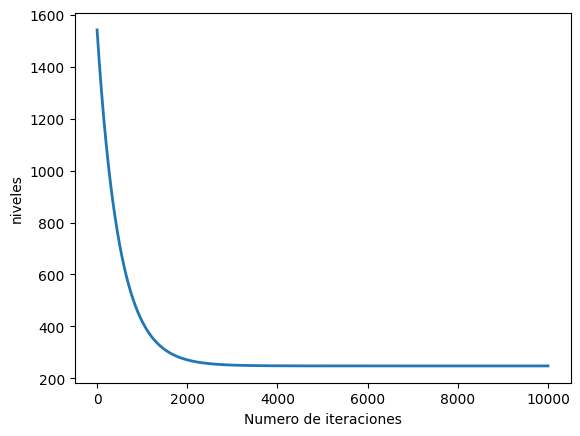

In [112]:
# Configurar los parámetros para el descenso por gradiente y ejecutarlo para regresión multivariable.
# Graficar la convergencia del costo.
# Imprimir los valores finales de theta.
# Estimar los niveles para una casa con características específicas utilizando los parámetros aprendidos.
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('niveles')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el precio para una casa de 1650 sq-ft, con 3 dormitorios
# Assuming the features for prediction are 1650 (sq-ft) and 8 (number of bedrooms)
# and other features are 0 for demonstration purposes. Replace with actual values.
X_predict = np.array([1650.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) # 9 features
X_predict_normalized = (X_predict - mu) / sigma # Normalize all 9 features
X_predict_final = np.concatenate([np.ones(1), X_predict_normalized]) # Add the intercept term
price = np.dot(X_predict_final, theta)

print('Los niveles de una casa tomando en cuenta su costo: {:.0f}'.format(price))

In [113]:
# Preparar un ejemplo específico de características para la predicción en regresión multivariable, normalizarlas y añadir el término de intercepción.
# Realizar la predicción utilizando los parámetros aprendidos y imprimir el resultado.
# Assuming the features for prediction are 1650 (sq-ft), 8 (number of bedrooms), and other features as 0
X_predict = np.array([1650.0, 8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) # 9 features
X_predict_normalized = (X_predict - mu) / sigma # Normalize all 9 features
X_predict_final = np.concatenate([np.ones(1), X_predict_normalized]) # Add the intercept term
price = np.dot(X_predict_final, theta)

print('Predicted price for a house with the given features: {:.0f}'.format(price))

Predicted price for a house with the given features: 53


In [114]:
# Cargar los datos nuevamente para usar la ecuación normal en regresión multivariable, esta vez sin normalizar.
# Añadir una columna de unos para el término de intercepción.
# Cargar datos
data = np.loadtxt('/content/gdrive/MyDrive/Colab Notebooks/DATASETS/DATASET-REAL-ESTATE2.txt', delimiter=',')
X = data[:, :2]
y = data[:, 2]
m = y.size
print(m)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

10000


In [115]:
# Definir la función para calcular los parámetros theta utilizando la ecuación normal (repetido).
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [116]:
# Calcular los parámetros theta utilizando la ecuación normal para regresión multivariable.
# Imprimir los valores de theta calculados.
# Estimar el precio para una casa con características específicas utilizando los parámetros de la ecuación normal.
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

X_array = [1, 500, 5]
price = np.dot(X_array, theta)

print('Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [5.63909314e+00 2.31696526e-04 9.37217564e-01]
Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): $10


REGRESION POLINOMICA

In [117]:
# Montar Google Drive para acceder a los archivos (repetido para la sección de regresión polinómica).
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [118]:
# Importar bibliotecas necesarias para manejo de directorios, computación numérica y graficación (repetido).
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [119]:
# Cargar datos desde un archivo CSV en Google Drive para regresión polinómica.
# Dividir los datos en característica (X) y variable objetivo (y).
# Imprimir los primeros 20 ejemplos.
# Cargar datos
#data = np.loadtxt(os.path.join('Datasets', 'capacidad_adquisitiva.csv'), delimiter=';')
#from numpy import genfromtxt
#data = genfromtxt(os.path.join('Datasets', 'capacidad_adquisitiva.csv'), delimiter=';')
data = np.loadtxt('/content/gdrive/MyDrive/Colab Notebooks/DATASETS/DATASET-REAL-ESTATE (1).csv', delimiter=",", skiprows=1)
#print(data)
X = data[:, :1]
y = data[:, 1]
m = y.size
#print(X)
#print(y)
# imprimir algunos puntos de datos
#print('{:>8s}{:>10s}'.format(X, y))
#print('-'*26)
for i in range(20):
    print('{:8.0f}{:10.0f}'.format(X[i, 0], y[i]))

      25        15
      14         5
     107         4
      31         3
      25         2
      14         5
      90         2
      30         1
      23        16
      23         2
      34         1
      34         1
      50         8
      32         5
      38        19
     111         3
      89        10
      26         6
      23         2
      25         5


In [120]:
# Definir una función para graficar los puntos de datos.
def plotData(x, y):
    #Grafica los puntos x e y en una figura nueva.

    fig = pyplot.figure()  # abre una nueva figura

    pyplot.plot(x, y, 'ro', ms=10, mec='k')
    pyplot.ylabel('Edad personas')
    pyplot.xlabel('Capacidad adquisitiva 1,000s')

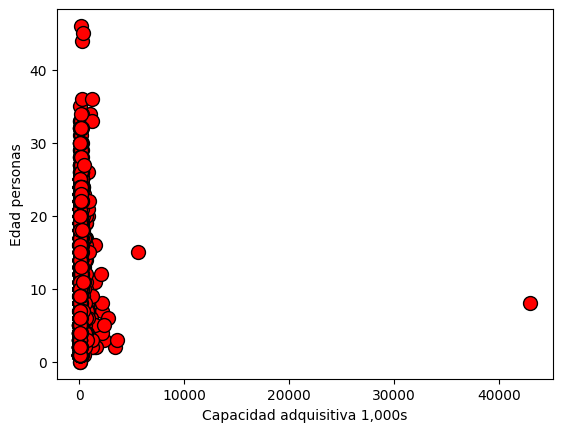

In [121]:
# Graficar los datos cargados utilizando la función plotData.
plotData(X, y)

In [122]:
# Añadir una característica polinómica (X al cuadrado) a la matriz de características.
X = np.concatenate([X, X * X], axis=1)

In [123]:
# Imprimir la matriz de características con la característica polinómica añadida.
print(X)

[[2.45130000e+01 6.00887169e+02]
 [1.45000000e+01 2.10250000e+02]
 [1.07000000e+02 1.14490000e+04]
 ...
 [1.45480000e+02 2.11644304e+04]
 [2.95000000e+01 8.70250000e+02]
 [2.52247000e+01 6.36285490e+02]]


In [124]:
# Definir una función para normalizar las características (repetido).
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [125]:
# Normalizar las características, incluyendo la característica polinómica, utilizando la función featureNormalize.
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

#print(X)
#print('Media calculada:', mu)
#print('Desviación estandar calculada:', sigma)
#print(X_norm)

In [126]:
# Imprimir la matriz de características normalizadas.
print(X_norm)

[[-0.08904216 -0.01101984]
 [-0.11141803 -0.01104096]
 [ 0.0952901  -0.01043323]
 ...
 [ 0.18128069 -0.00990787]
 [-0.07789779 -0.01100527]
 [-0.08745173 -0.01101792]]


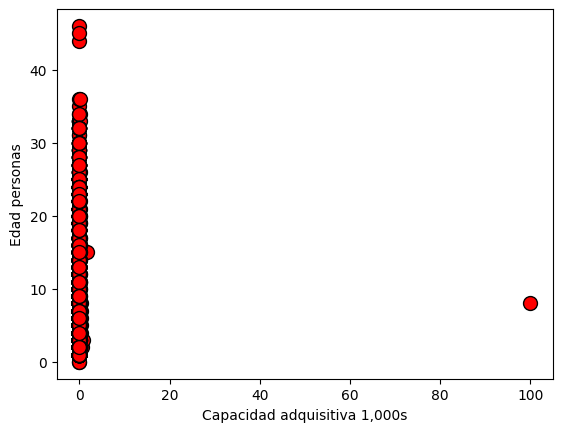

In [127]:
# Graficar la característica polinómica normalizada contra la variable objetivo.
plotData(X_norm[:,1], y)

In [128]:
# Añadir una columna de unos a la matriz de características normalizadas para el término de intercepción.
# (Columna de unos para X0)
#X_norm = np.concatenate([X_norm, X_norm * X_norm], axis=1)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [129]:
# Imprimir la matriz de características normalizadas con la columna de intercepción añadida.
print(X)

[[ 1.         -0.08904216 -0.01101984]
 [ 1.         -0.11141803 -0.01104096]
 [ 1.          0.0952901  -0.01043323]
 ...
 [ 1.          0.18128069 -0.00990787]
 [ 1.         -0.07789779 -0.01100527]
 [ 1.         -0.08745173 -0.01101792]]


In [130]:
# Definir la función para calcular la función de costo (Mean Squared Error) (repetido).
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [131]:
# Definir la función para realizar el descenso por gradiente (repetido).
# Actualiza los parámetros theta iterativamente para minimizar la función de costo.
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [ 6.76599434  1.16073887 -1.01374043]
La capacidad adquisitiva para una persona de 33 (usando el descenso por el gradiente): $7


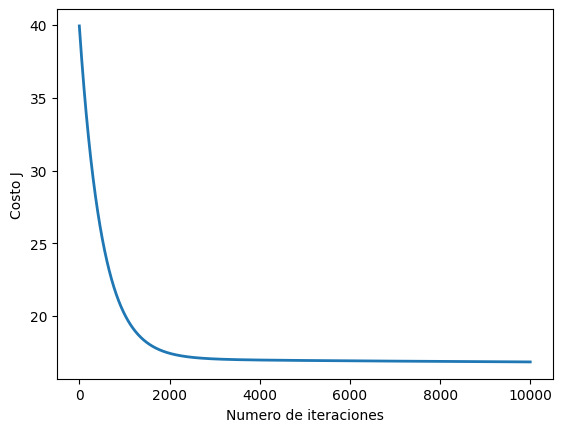

In [132]:
# Configurar los parámetros para el descenso por gradiente y ejecutarlo para regresión polinómica.
# Graficar la convergencia del costo.
# Imprimir los valores finales de theta.
# Estimar la capacidad adquisitiva para una edad específica utilizando los parámetros aprendidos.
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(3)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# La capacidad adquisitiva de una persona de 33 años
X_array = [1, 34, 1156]
X_array[1:3] = (X_array[1:3] - mu) / sigma
price = np.dot(X_array, theta)   # Se debe cambiar esto

print('La capacidad adquisitiva para una persona de 33 (usando el descenso por el gradiente): ${:.0f}'.format(price))

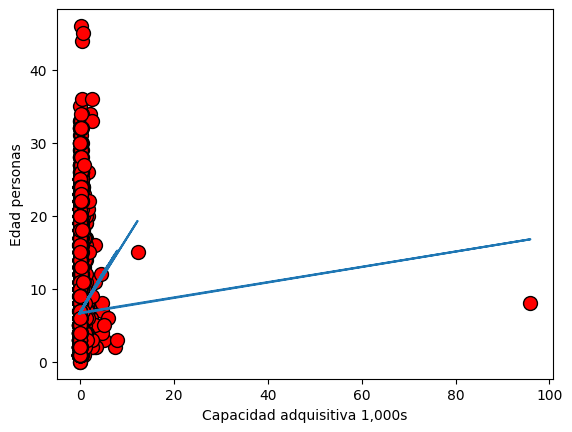

In [133]:
# Graficar los datos originales y la línea de regresión polinómica obtenida por el descenso por gradiente.
plotData(X[:, 1], y)
pyplot.plot(X[:, 1], np.dot(X, theta), '-')

In [134]:
# Preparar un ejemplo específico de características para la predicción en regresión polinómica, incluyendo el término polinómico, normalizarlas.
X_array = [1, 23, 529]
X_array[1:3] = (X_array[1:3] - mu) / sigma

In [135]:
# Realizar la predicción utilizando los parámetros aprendidos y imprimir el resultado.
X_array[1:3]
print(np.dot(X_array, theta))

6.669890301690584


In [136]:
# Cargar los datos nuevamente para usar la ecuación normal en regresión polinómica.
# Crear características polinómicas y añadir una columna de unos para el término de intercepción.
# Cargar datos
data = np.loadtxt('/content/gdrive/MyDrive/Colab Notebooks/DATASETS/DATASET-REAL-ESTATE (1).csv', delimiter=",",skiprows=1)
X = data[:, :1]
y = data[:, 1]
m = y.size
X_original = X.copy()
X = np.concatenate([X, X * X], axis=1)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

In [137]:
# Definir la función para calcular los parámetros theta utilizando la ecuación normal (repetido).
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [138]:
# Calcular los parámetros theta utilizando la ecuación normal para regresión polinómica.
# Imprimir los valores de theta calculados.
# Estimar la capacidad adquisitiva para una edad específica utilizando los parámetros de la ecuación normal.
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

X_array = [1, 20, 400]
price = np.dot(X_array, theta)

print('Capacidad adquisitica para una edad de 20 años(usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [ 6.27704008e+00  8.20758800e-03 -1.90657698e-07]
Capacidad adquisitica para una edad de 20 años(usando la ecuación de la normal): $6


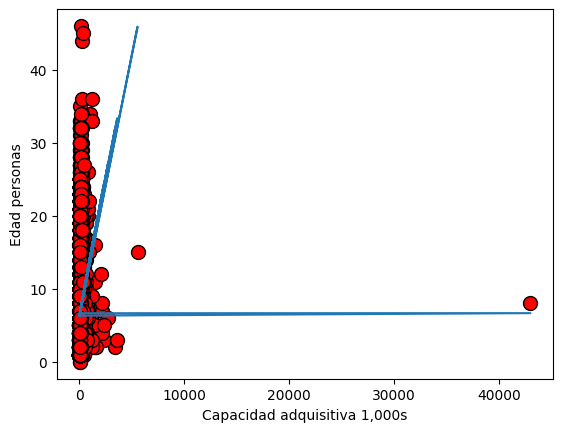

In [139]:
# Graficar los datos originales y la línea de regresión polinómica obtenida por la ecuación normal.
plotData(X[:, 1], y)
#X = np.concatenate([np.ones((m, 1)), X], axis=1)
#X = np.concatenate([X, X * X], axis=1)

pyplot.plot(X[:, 1], np.dot(X, theta), '-')

In [109]:
# Imprimir la matriz de características con la columna de intercepción añadida (repetido).
print(X)

[[ 1.         -0.08904216  1.40817421 ... -1.28458043  1.43984053
   1.32608359]
 [ 1.         -0.11141803 -0.30208267 ... -1.28458043 -0.69452136
   0.17676453]
 [ 1.          0.0952901  -0.47310836 ...  0.51295737 -0.69452136
  -1.0082519 ]
 ...
 [ 1.          0.18128069  2.60535403 ... -1.28458043  1.43984053
  -1.17385655]
 [ 1.         -0.07789779  0.38202008 ...  1.11213664 -0.69452136
   1.35070837]
 [ 1.         -0.08745173 -0.13105698 ... -1.28458043  1.43984053
  -1.70616245]]
